# 1. Importing the libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load the data

In [60]:
# Load the CSV file
# Keep this CSV file in the same folder as the notebook

df = pd.read_csv('retail_store_inventory.csv')

df_clean = pd.read_csv('retail_cleaned.csv')



# Display first 5 rows
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [91]:
pd.set_option('display.max_columns', None)
df_clean.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,dataset_demand_forecast,price,discount,weather_condition,holiday_or_promo_flag,competitor_price,seasonality,store_id_encoded,product_id_encoded,category_encoded,region_encoded,weather_condition_encoded,seasonality_encoded,units_sold_log,demand_forecast_log
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,0,0,3,1,1,0,4.852030,4.916105
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,0,1,4,2,3,0,5.017280,4.977010
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,0,2,4,3,3,2,4.189655,4.317755
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,0,3,4,1,0,0,4.127134,4.145988
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,0,4,1,0,3,2,2.708050,2.328253


# 3. Basic structure check

In [62]:
# Number of rows and columns
df.shape

(73100, 15)

In [63]:
# Column names
df.columns.tolist()

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Demand Forecast',
 'Price',
 'Discount',
 'Weather Condition',
 'Holiday/Promotion',
 'Competitor Pricing',
 'Seasonality']

In [64]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 11.4 MB


In [65]:
# Random sample of rows
# This is often better than only checking the first 5 rows

df.sample(5, random_state=42)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
66127,2023-10-24,S002,P0008,Electronics,North,225,138,144,139.31,40.47,0,Snowy,1,41.97,Winter
43485,2023-03-11,S005,P0006,Toys,North,200,105,119,117.55,18.65,15,Cloudy,1,16.65,Spring
34304,2022-12-10,S001,P0005,Clothing,East,145,70,137,78.51,20.33,15,Snowy,0,18.04,Winter
34317,2022-12-10,S001,P0018,Electronics,West,350,105,157,103.11,98.65,15,Sunny,0,95.43,Spring
38631,2023-01-22,S002,P0012,Groceries,North,145,76,145,92.47,10.04,20,Sunny,0,13.01,Winter


In [66]:
data_dictionary = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str),
    "example_value": [df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else None for col in df.columns],
    "unique_values": [df[col].nunique() for col in df.columns]
})

data_dictionary

,column_name,data_type,example_value,unique_values
Date,Date,str,2022-01-01,731
Store ID,Store ID,str,S001,5
Product ID,Product ID,str,P0001,20
Category,Category,str,Groceries,5
Region,Region,str,North,4
Inventory Level,Inventory Level,int64,231,451
Units Sold,Units Sold,int64,127,498
Units Ordered,Units Ordered,int64,55,181
Demand Forecast,Demand Forecast,float64,135.47,31608
Price,Price,float64,33.5,8999


# 4. Summary statistics

In [67]:
# Summary statistics for numerical columns
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [68]:
# Summary statistics for categorical columns
df.describe(include='object')

C:\Users\mshak\AppData\Local\Temp\ipykernel_2848\2262309595.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Date,Store ID,Product ID,Category,Region,Weather Condition,Seasonality
count,73100,73100,73100,73100,73100,73100,73100
unique,731,5,20,5,4,4,4
top,2022-01-01,S001,P0001,Furniture,East,Sunny,Spring
freq,100,14620,3655,14699,18349,18290,18317


# 5. Duplicate record check

In [69]:
# Count exact duplicate rows
df.duplicated().sum()

np.int64(0)

In [70]:
# Example: check duplicate records based on business-like keys

key_columns = ['Date', 'Store ID', 'Category', 'Region']

duplicate_key_count = df.duplicated(subset=key_columns).sum()
duplicate_key_count

np.int64(26153)

There is no duplication in this dataset

# 6. Missing value analysis

In [71]:
# Count missing values
missing_count = df.isnull().sum().sort_values(ascending=False)

# Missing percentage
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage


There is no any missing values from any records

# 7. Checking Invalid Dates

In [72]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# invalid dates
df['Date'].isnull().sum()

np.int64(0)

All dates are valid in this dataset

# 8. Sales Value Check

In [73]:
df[df['Units Sold'] < 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality


There is no negative sales value 

In [74]:
df[df['Units Sold'] == 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
63,2022-01-01,S004,P0004,Groceries,West,437,0,160,-2.40,87.23,10,Sunny,0,90.36,Spring
159,2022-01-02,S003,P0020,Electronics,East,155,0,92,9.42,57.07,10,Rainy,1,53.34,Summer
303,2022-01-04,S001,P0004,Electronics,North,209,0,123,15.37,44.81,5,Sunny,1,45.53,Winter
1107,2022-01-12,S001,P0008,Clothing,West,432,0,33,-3.55,55.07,0,Cloudy,0,51.15,Autumn
1398,2022-01-14,S005,P0019,Groceries,West,65,0,122,-0.03,82.34,20,Rainy,1,79.80,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71239,2023-12-14,S002,P0020,Clothing,West,135,0,148,0.35,90.15,15,Cloudy,0,85.24,Winter
72053,2023-12-22,S003,P0014,Toys,South,421,0,133,-4.03,11.71,15,Cloudy,0,12.11,Summer
72078,2023-12-22,S004,P0019,Electronics,East,301,0,24,-9.08,59.17,5,Cloudy,1,58.16,Autumn
72463,2023-12-26,S004,P0004,Electronics,North,101,0,70,16.66,72.31,20,Snowy,1,76.93,Summer


There are 0 unit stocks

# 9. Negative Inventory Check

In [75]:
df[df['Inventory Level'] < 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality


There is no negative inventory value

# 10. Negative Demand Forecast Check

In [76]:
df[df['Demand Forecast'] < 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
63,2022-01-01,S004,P0004,Groceries,West,437,0,160,-2.40,87.23,10,Sunny,0,90.36,Spring
141,2022-01-02,S003,P0002,Groceries,East,175,2,140,-3.40,87.50,0,Rainy,0,91.20,Autumn
278,2022-01-03,S004,P0019,Toys,North,140,1,47,-3.91,80.41,0,Snowy,0,76.90,Winter
511,2022-01-06,S001,P0012,Groceries,North,59,1,88,-8.37,63.21,0,Rainy,0,60.48,Spring
730,2022-01-08,S002,P0011,Electronics,South,64,7,79,-2.99,92.43,0,Snowy,0,88.55,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72716,2023-12-29,S001,P0017,Clothing,North,487,7,132,-0.73,55.34,0,Sunny,1,58.03,Summer
72722,2023-12-29,S002,P0003,Toys,West,199,4,180,-5.50,82.08,10,Cloudy,1,77.99,Spring
72859,2023-12-30,S003,P0020,Toys,North,203,1,119,-7.68,94.33,5,Sunny,1,96.79,Autumn
73026,2024-01-01,S002,P0007,Toys,West,53,2,40,-6.08,63.66,20,Snowy,1,62.37,Autumn


There is negative Demand Forecast value!

# 10. Unusual Price Values Check

In [77]:
df[df['Price'] < 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality


In [78]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Price'] < Q1 - 1.5*IQR) | (df['Price'] > Q3 + 1.5*IQR)]
outliers

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality


# 11. Unusual Unit Sold Values Check

In [79]:
Q1 = df['Units Sold'].quantile(0.25)
Q3 = df['Units Sold'].quantile(0.75)
IQR = Q3 - Q1

sales_outliers = df[(df['Units Sold'] < Q1 - 1.5*IQR) | (df['Units Sold'] > Q3 + 1.5*IQR)]
sales_outliers

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
102,2022-01-02,S001,P0003,Clothing,South,488,464,163,463.12,70.99,10,Snowy,0,72.93,Summer
138,2022-01-02,S002,P0019,Toys,East,492,479,132,469.74,79.11,0,Cloudy,0,80.06,Winter
195,2022-01-02,S005,P0016,Groceries,East,487,437,106,432.86,43.64,15,Cloudy,1,39.13,Autumn
322,2022-01-04,S002,P0003,Toys,North,493,448,113,459.44,41.55,15,Rainy,0,44.02,Winter
554,2022-01-06,S003,P0015,Furniture,North,490,476,53,478.76,20.66,0,Rainy,1,16.87,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72428,2023-12-26,S002,P0009,Clothing,South,485,453,172,444.97,82.93,15,Cloudy,1,79.35,Autumn
72485,2023-12-26,S005,P0006,Groceries,West,498,482,33,488.92,34.79,10,Sunny,1,31.68,Autumn
72567,2023-12-27,S004,P0008,Furniture,East,493,441,79,435.81,91.84,20,Rainy,1,88.97,Summer
72884,2023-12-30,S005,P0005,Furniture,East,498,472,169,485.17,95.79,20,Sunny,1,98.65,Summer


There are extreme value of units sold

# 12. Checking Missing Product / Store Combinations

In [80]:
df.groupby(['Store ID', 'Product ID']).size().reset_index(name='count')

,Store ID,Product ID,count
0,S001,P0001,731
1,S001,P0002,731
2,S001,P0003,731
3,S001,P0004,731
4,S001,P0005,731
...,...,...,...
95,S005,P0016,731
96,S005,P0017,731
97,S005,P0018,731
98,S005,P0019,731


In [81]:
all_stores = df['Store ID'].unique()
all_products = df['Product ID'].unique()

expected = len(all_stores) * len(all_products)
actual = df[['Store ID', 'Product ID']].drop_duplicates().shape[0]

print("Expected combinations:", expected)
print("Actual combinations:", actual)

Expected combinations: 100
Actual combinations: 100


All stores have the all products, so not any store miss any product

# 13 Checking data continuity error

In [82]:
df_sorted = df.sort_values(['Store ID', 'Product ID', 'Date'])

# check gaps
df_sorted['date_diff'] = df_sorted.groupby(['Store ID', 'Product ID'])['Date'].diff()

df_sorted[df_sorted['date_diff'].dt.days > 1]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,date_diff


This confirms that all dates are available

# 14. Numerical variable analysis

In [83]:
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols

['inventory_level',
 'units_sold',
 'units_ordered',
 'dataset_demand_forecast',
 'price',
 'discount',
 'holiday_or_promo_flag',
 'competitor_price',
 'store_id_encoded',
 'product_id_encoded',
 'category_encoded',
 'region_encoded',
 'weather_condition_encoded',
 'seasonality_encoded',
 'units_sold_log',
 'demand_forecast_log']

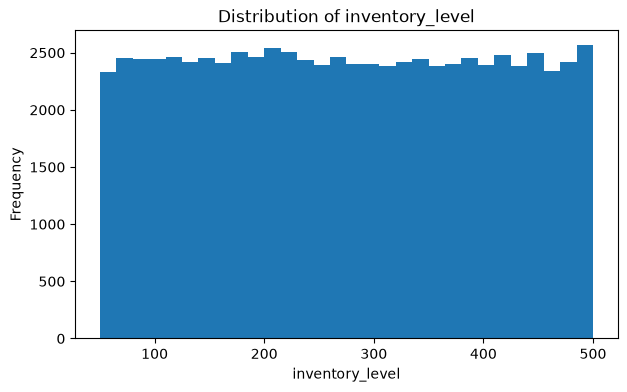

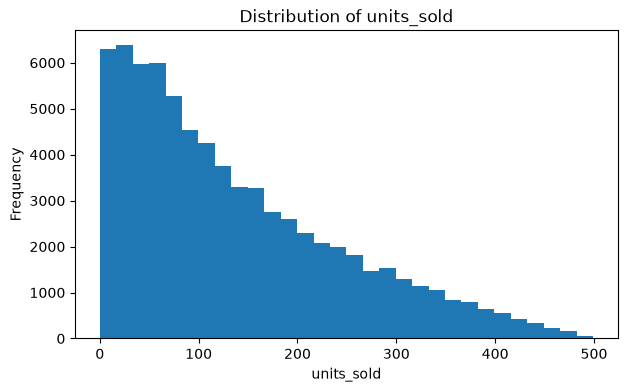

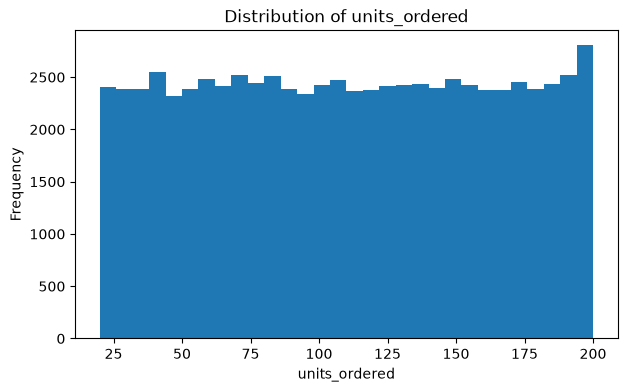

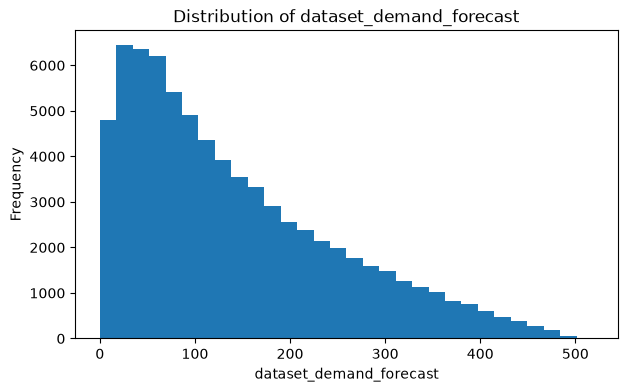

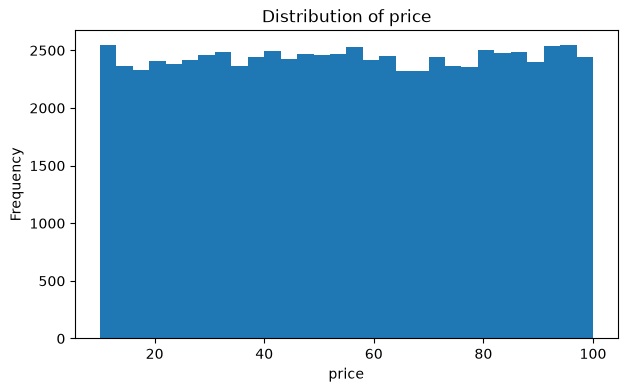

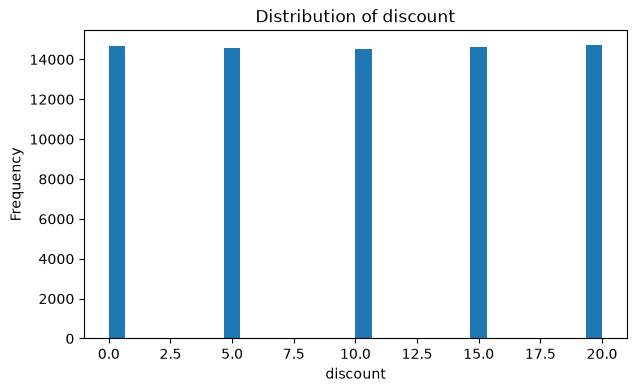

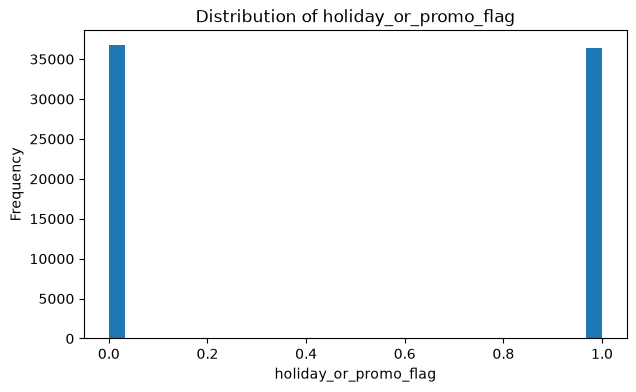

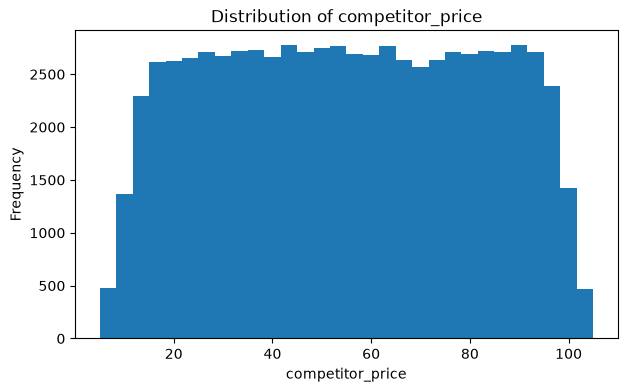

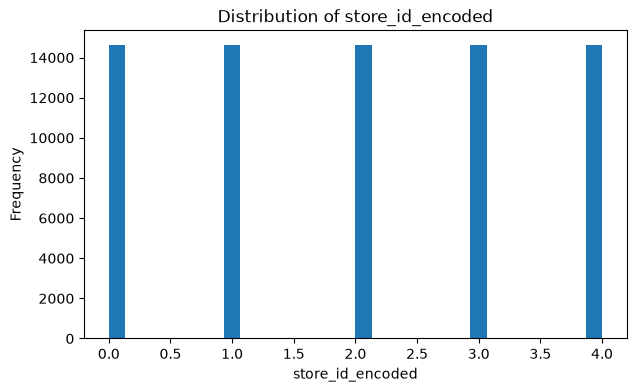

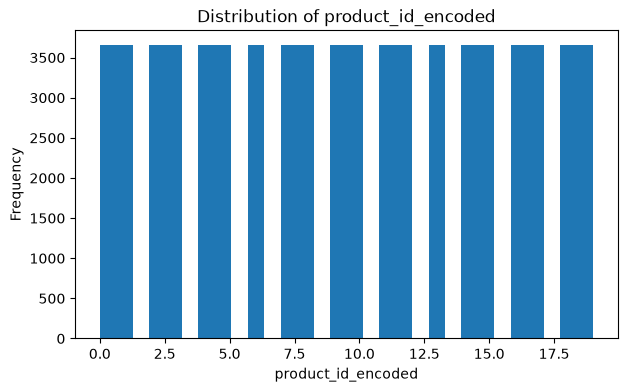

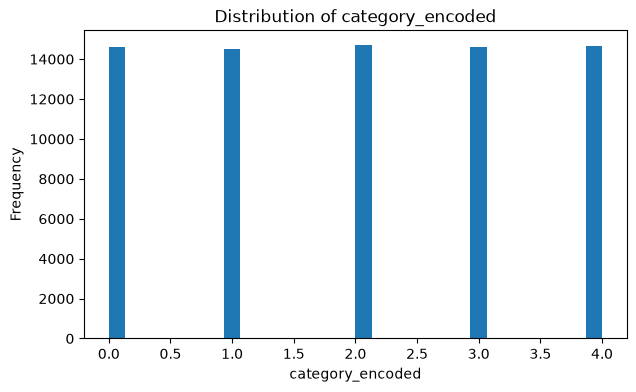

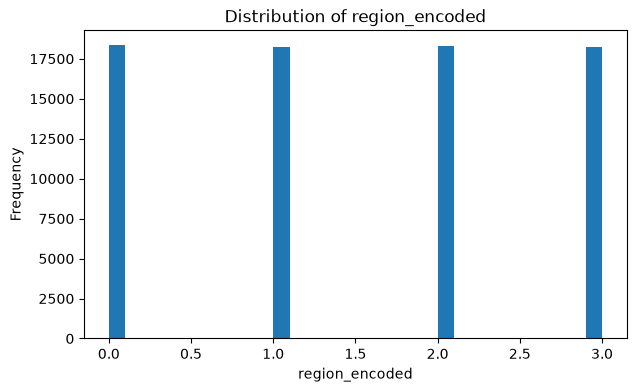

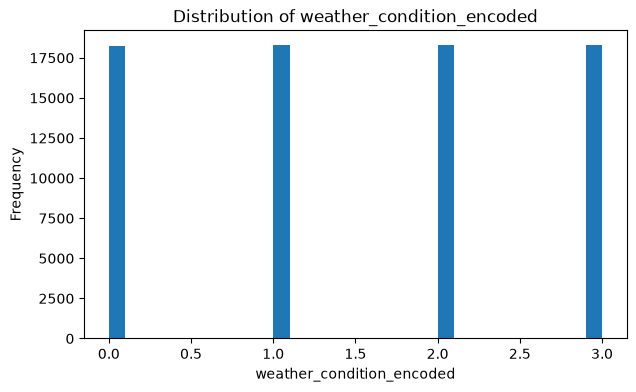

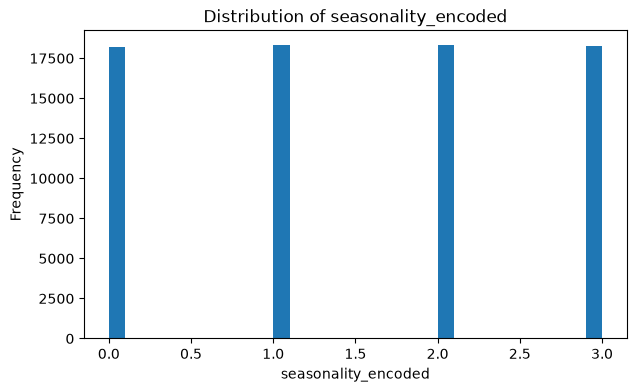

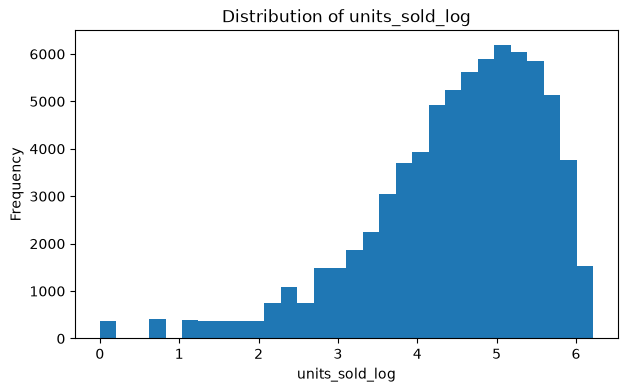

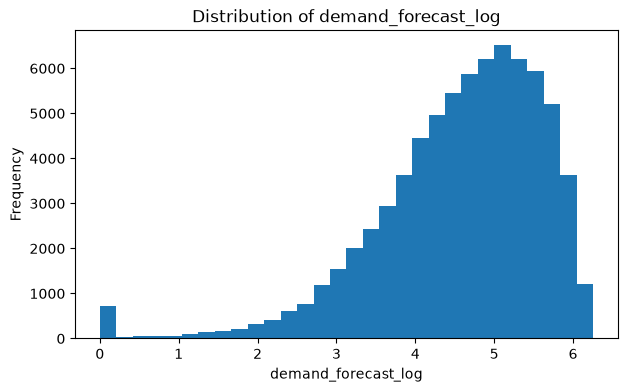

In [84]:
# Plot histograms for all numerical columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    df_clean[col].plot(kind='hist', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

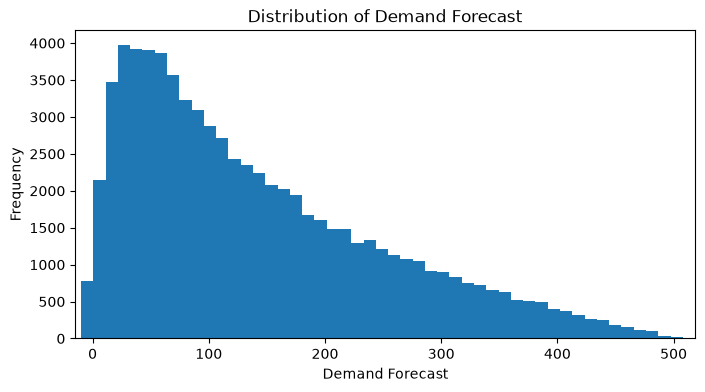

In [85]:
plt.figure(figsize=(8, 4))

plt.hist(df['Demand Forecast'], bins=50)

plt.xlim(-15, df['Demand Forecast'].max())  # show negative values clearly

plt.title('Distribution of Demand Forecast')
plt.xlabel('Demand Forecast')
plt.ylabel('Frequency')

plt.show()

In [86]:
df[df['Demand Forecast'] < 0].shape[0]

673

# 15. Categorical variable analysis

In [87]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

C:\Users\mshak\AppData\Local\Temp\ipykernel_2848\611271536.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


['Store ID',
 'Product ID',
 'Category',
 'Region',
 'Weather Condition',
 'Seasonality']

In [88]:
# Frequency count for each categorical column

for col in categorical_cols:
    print("\nColumn:", col)
    print(df[col].value_counts())


Column: Store ID
Store ID
S001    14620
S002    14620
S003    14620
S004    14620
S005    14620
Name: count, dtype: int64

Column: Product ID
Product ID
P0001    3655
P0002    3655
P0003    3655
P0004    3655
P0005    3655
P0006    3655
P0007    3655
P0008    3655
P0009    3655
P0010    3655
P0011    3655
P0012    3655
P0013    3655
P0014    3655
P0015    3655
P0016    3655
P0017    3655
P0018    3655
P0019    3655
P0020    3655
Name: count, dtype: int64

Column: Category
Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

Column: Region
Region
East     18349
South    18297
North    18228
West     18226
Name: count, dtype: int64

Column: Weather Condition
Weather Condition
Sunny     18290
Rainy     18278
Snowy     18272
Cloudy    18260
Name: count, dtype: int64

Column: Seasonality
Seasonality
Spring    18317
Summer    18305
Winter    18285
Autumn    18193
Name: count, dtype: int64


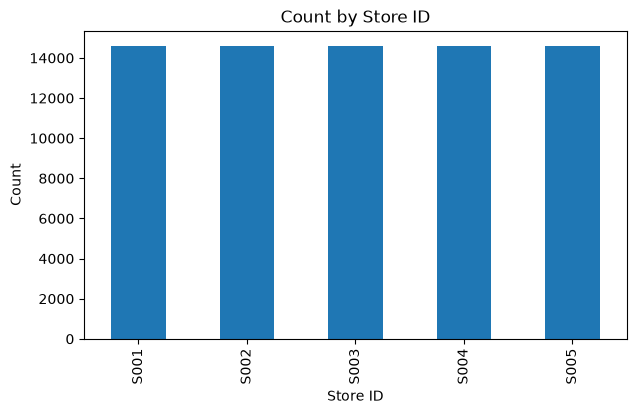

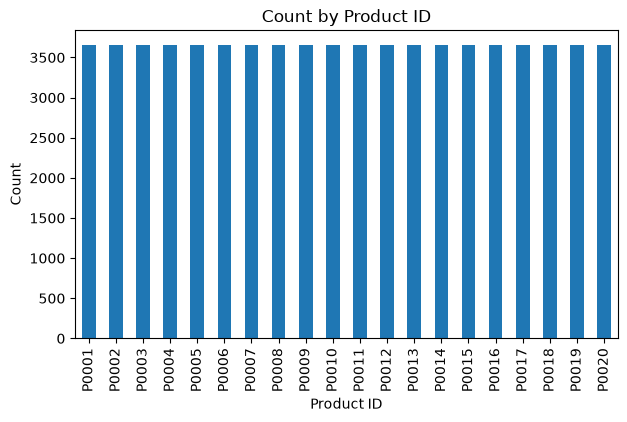

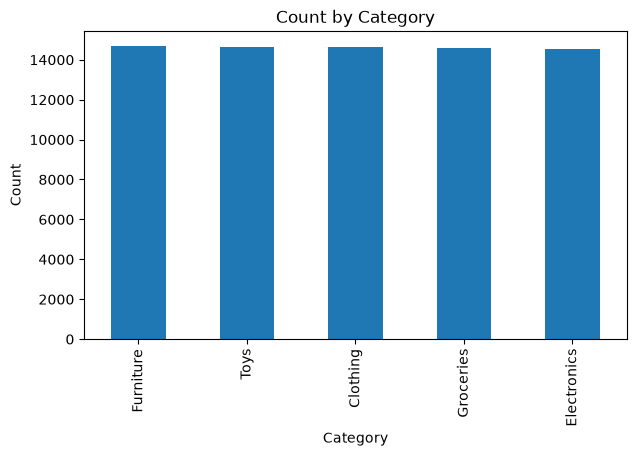

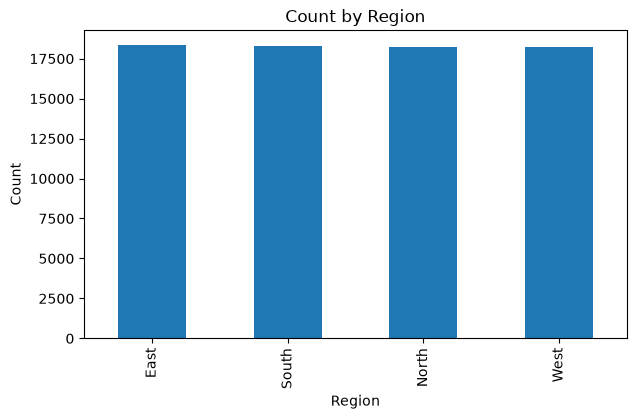

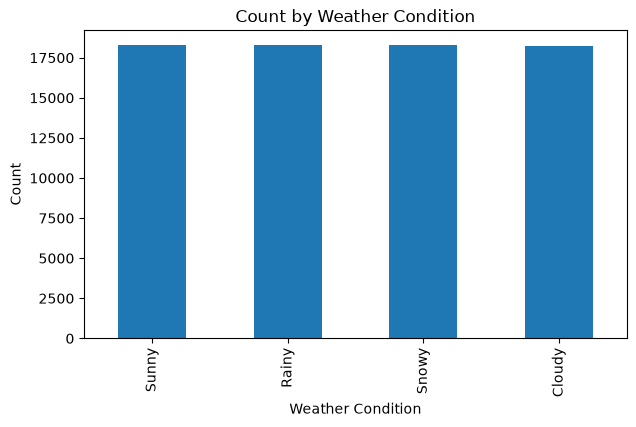

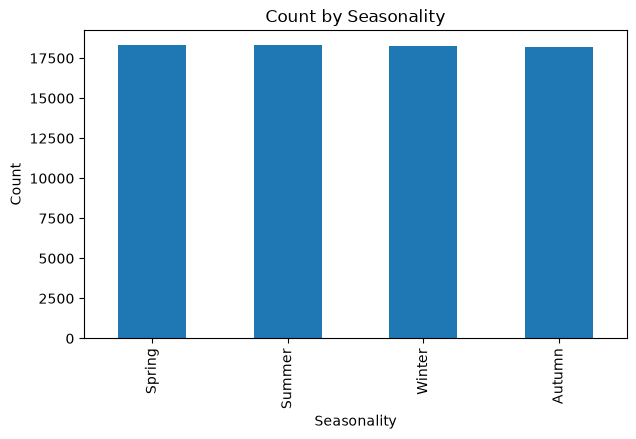

In [89]:
# Bar chart for key categorical columns

for col in ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']:
    plt.figure(figsize=(7, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# 16. Outlier detection

In [90]:
# Boxplot for all numerical columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    plt.boxplot(df[col].dropna(), vert=False)

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.show()

KeyError: 'inventory_level'

<Figure size 800x400 with 0 Axes>

Units Sold and Demand Forecast has extreme value

# 16. Relationship analysis

In [ ]:
# Correlation matrix for numerical columns

corr_cols = numeric_cols
corr_matrix = df[corr_cols].corr()
corr_matrix

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
Inventory Level,1.000000,0.589995,0.001060,0.588561,0.009140,0.004889,0.003411,0.009365
Units Sold,0.589995,1.000000,-0.000930,0.996853,0.001082,0.002576,-0.000374,0.001259
Units Ordered,0.001060,-0.000930,1.000000,-0.001102,0.004212,-0.000938,0.005446,0.004596
Demand Forecast,0.588561,0.996853,-0.001102,1.000000,0.000675,0.002338,-0.000526,0.000844
Price,0.009140,0.001082,0.004212,0.000675,1.000000,0.001509,0.002309,0.993900
Discount,0.004889,0.002576,-0.000938,0.002338,0.001509,1.000000,-0.000852,0.001958
Holiday/Promotion,0.003411,-0.000374,0.005446,-0.000526,0.002309,-0.000852,1.000000,0.001890
Competitor Pricing,0.009365,0.001259,0.004596,0.000844,0.993900,0.001958,0.001890,1.000000


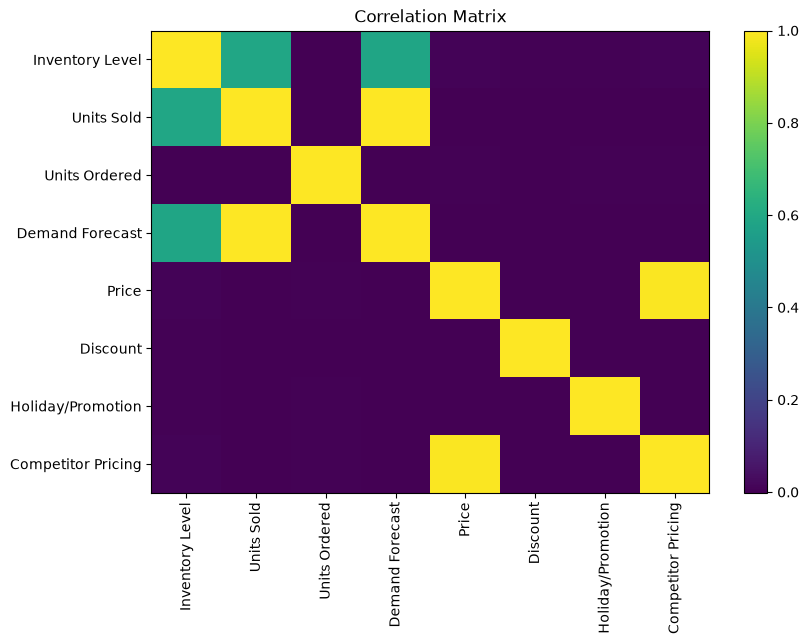

In [ ]:
# Correlation heatmap using matplotlib

plt.figure(figsize=(9, 6))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Matrix')
plt.show()

Unit vs Other Columns Relationship

C:\Users\mshak\AppData\Local\Temp\ipykernel_2848\451183619.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  numeric_cols = df.select_dtypes(include=['int64', 'float64', 'object']).columns


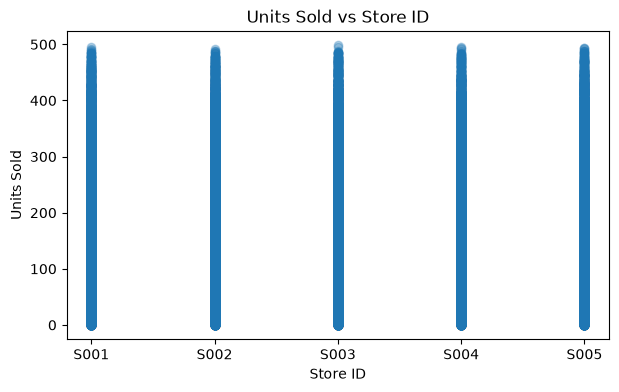

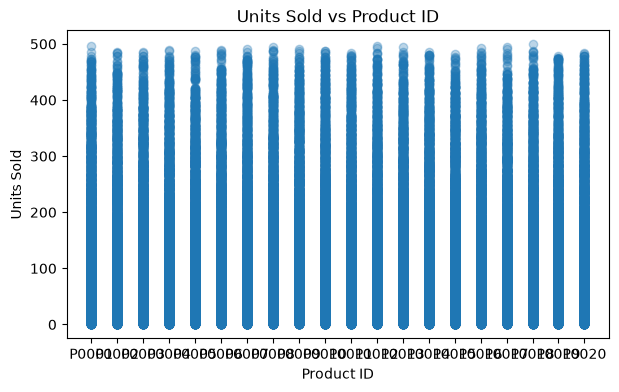

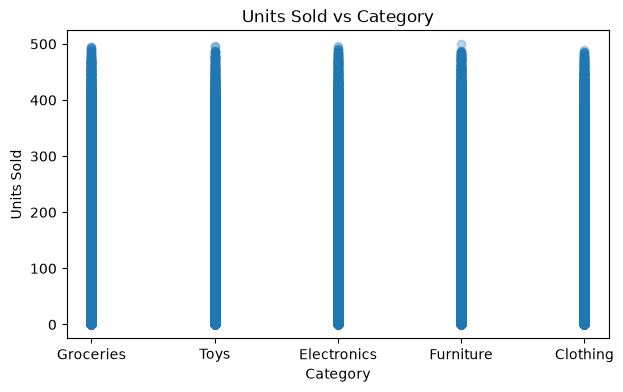

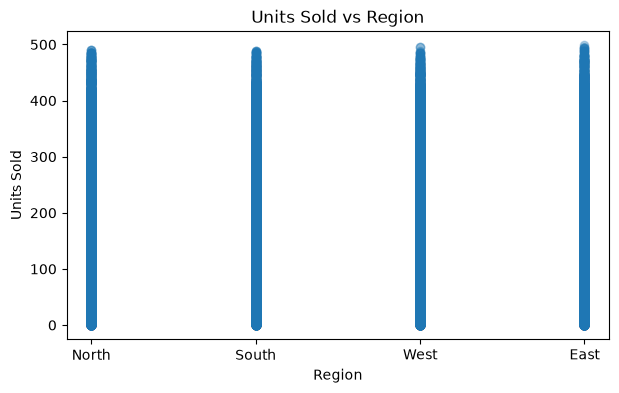

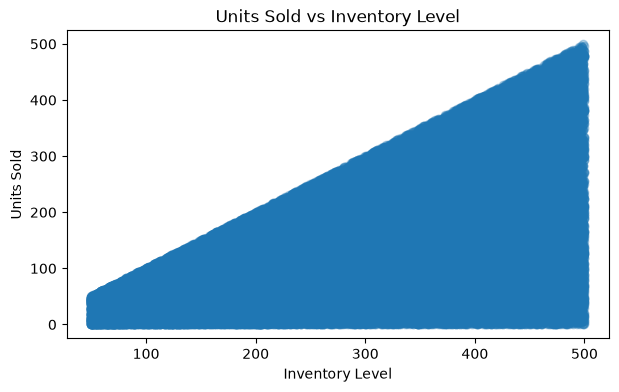

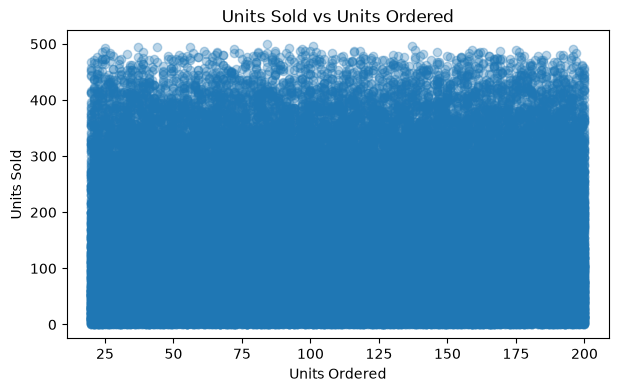

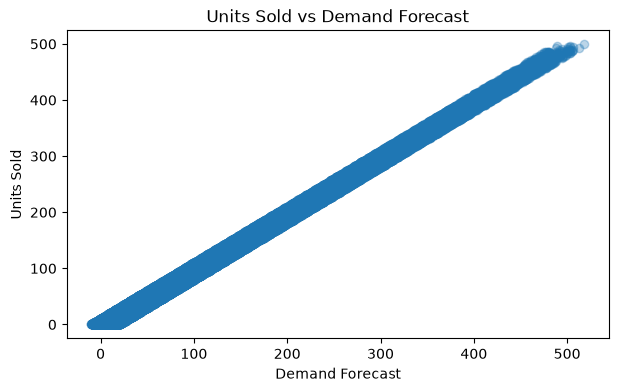

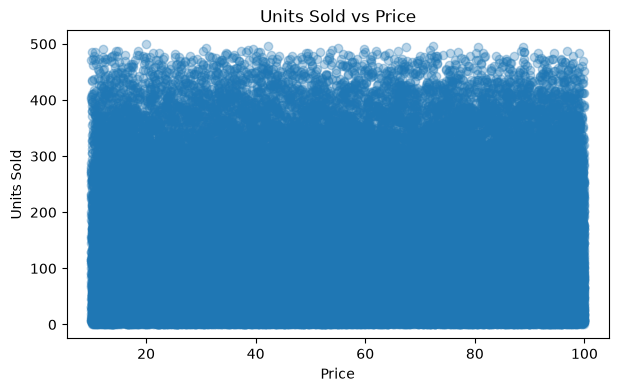

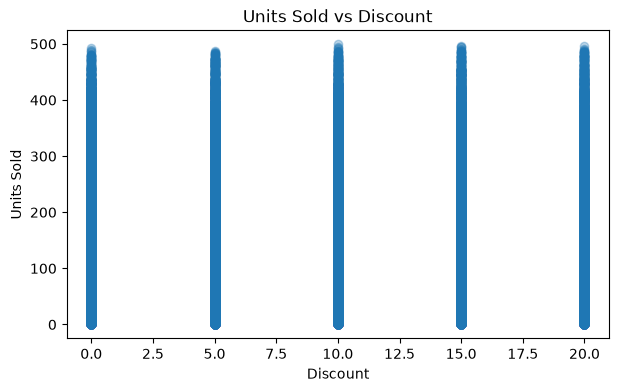

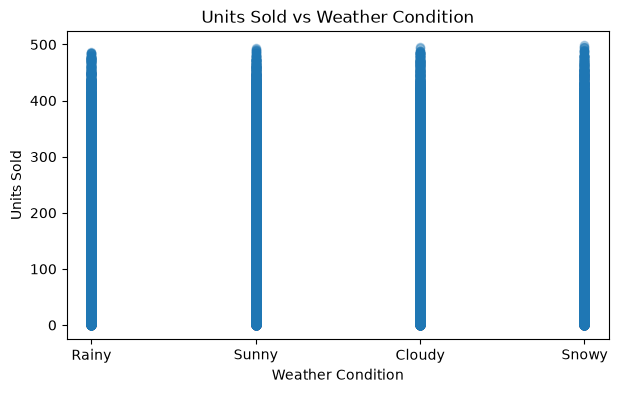

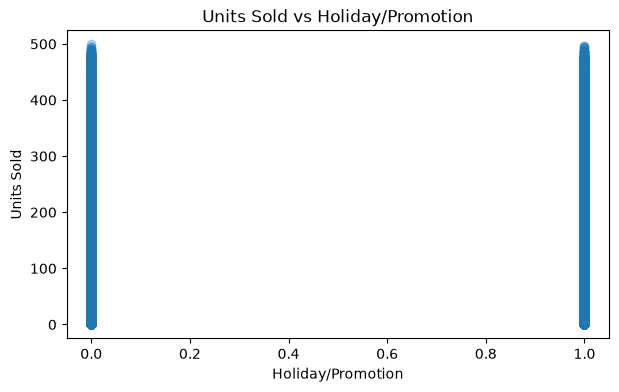

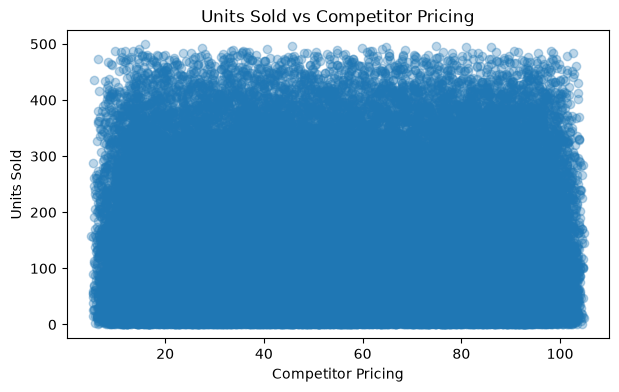

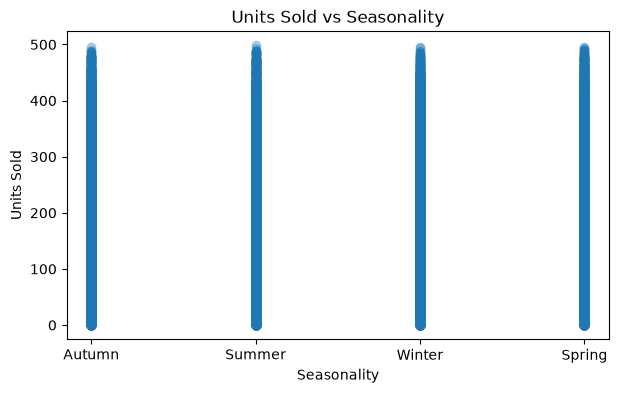

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'object']).columns

for col in numeric_cols:
    if col != 'Units Sold':
        plt.figure(figsize=(7,4))
        plt.scatter(df[col], df['Units Sold'], alpha=0.3)

        plt.title(f'Units Sold vs {col}')
        plt.xlabel(col)
        plt.ylabel('Units Sold')

        plt.show()

# 17. Time trend analysis

In [ ]:
top_products = (
    df.groupby('Product ID')['Units Sold']
      .sum()
      .sort_values(ascending=False)
)

top_products.head(10)

Product ID
P0016    508472
P0020    507708
P0014    507622
P0015    507283
P0005    503648
P0009    502086
P0013    500619
P0017    500510
P0011    499362
P0007    499321
Name: Units Sold, dtype: int64

# Which products sell the most?

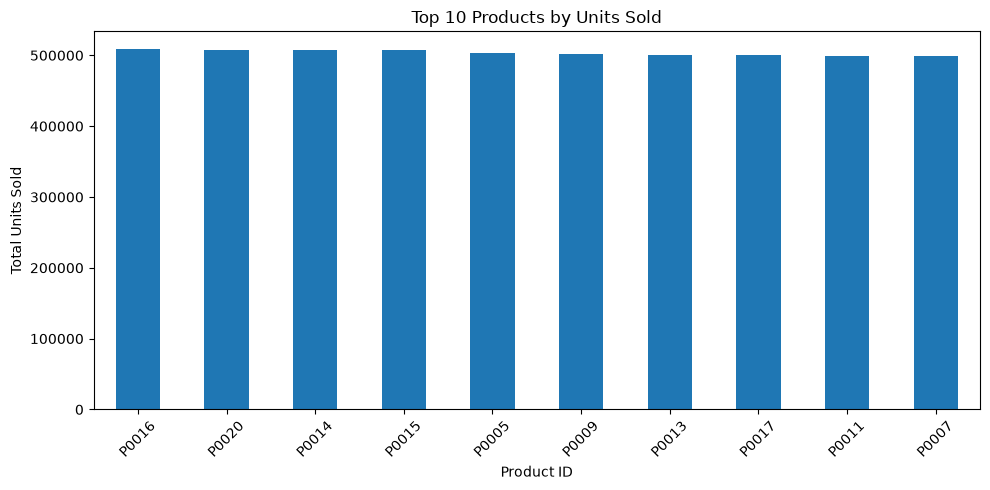

In [ ]:
plt.figure(figsize=(10, 5))

top_products.head(10).plot(kind='bar')

plt.title('Top 10 Products by Units Sold')
plt.xlabel('Product ID')
plt.ylabel('Total Units Sold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Which stores have higher demand?

In [ ]:
store_demand = (
    df.groupby('Store ID')['Units Sold']
      .sum()
      .sort_values(ascending=False)
)

store_demand

Store ID
S003    2022696
S005    2010176
S002    1987715
S004    1979245
S001    1975750
Name: Units Sold, dtype: int64

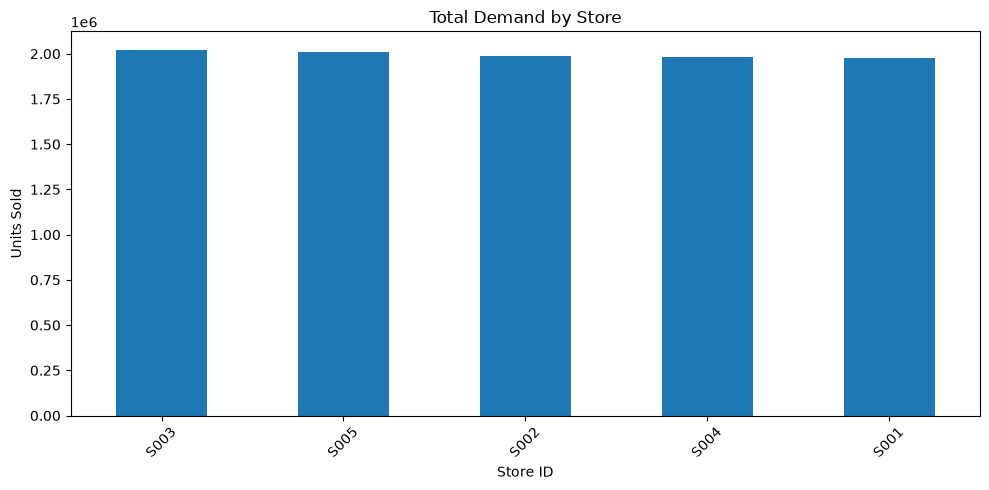

In [ ]:
plt.figure(figsize=(10, 5))

store_demand.plot(kind='bar')

plt.title('Total Demand by Store')
plt.xlabel('Store ID')
plt.ylabel('Units Sold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Which products have low inventory?

In [ ]:
low_inventory = (
    df.groupby('Product ID')['Inventory Level']
      .mean()
      .sort_values()
)

low_inventory.head(10)

Product ID
P0002    271.146101
P0004    271.556498
P0012    272.511902
P0018    272.538714
P0008    272.774829
P0011    272.807661
P0001    272.993981
P0005    273.041860
P0006    273.571272
P0019    274.525308
Name: Inventory Level, dtype: float64

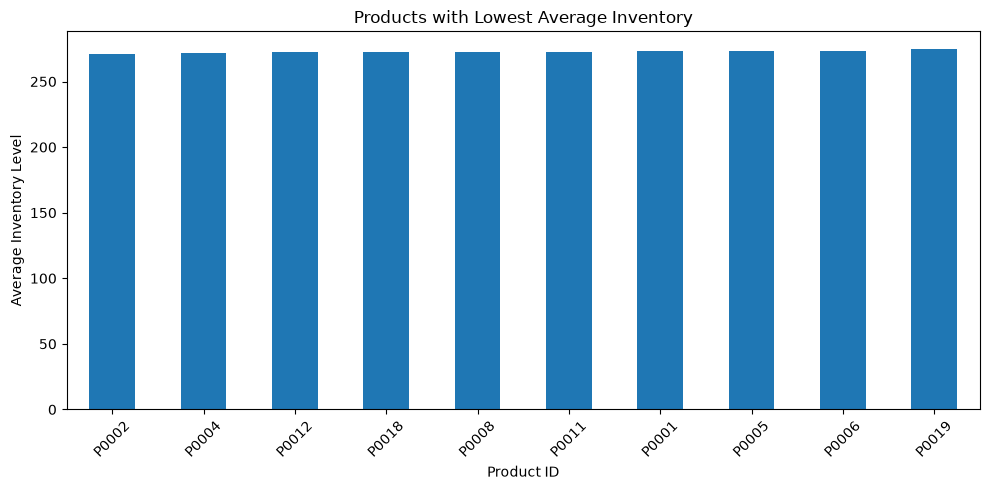

In [ ]:
plt.figure(figsize=(10, 5))

low_inventory.head(10).plot(kind='bar')

plt.title('Products with Lowest Average Inventory')
plt.xlabel('Product ID')
plt.ylabel('Average Inventory Level')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# What is the sales trend by week/month?

In [ ]:
df['YearMonth'] = df['Date'].dt.to_period('M')
df['YearWeek'] = df['Date'].dt.to_period('W')

monthly_sales = (
    df.groupby('YearMonth')['Units Sold']
      .sum()
)

monthly_sales

YearMonth
2022-01    419938
2022-02    391052
2022-03    426073
2022-04    407380
2022-05    414799
2022-06    415509
2022-07    426628
2022-08    424916
2022-09    411610
2022-10    426863
2022-11    414535
2022-12    412321
2023-01    423408
2023-02    385168
2023-03    416522
2023-04    401077
2023-05    418673
2023-06    405641
2023-07    437919
2023-08    416501
2023-09    405361
2023-10    425646
2023-11    416126
2023-12    418672
2024-01     13244
Freq: M, Name: Units Sold, dtype: int64

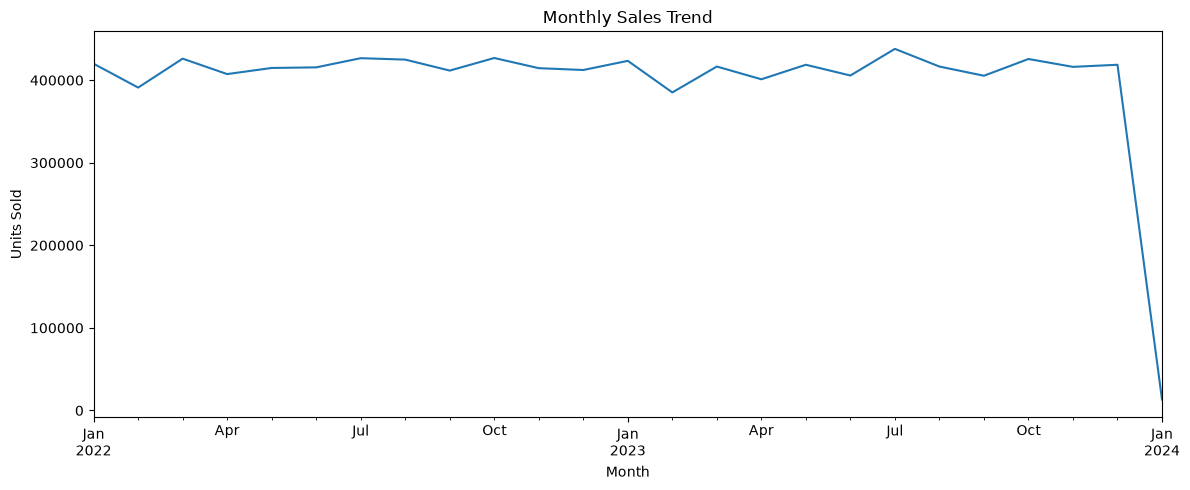

In [ ]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

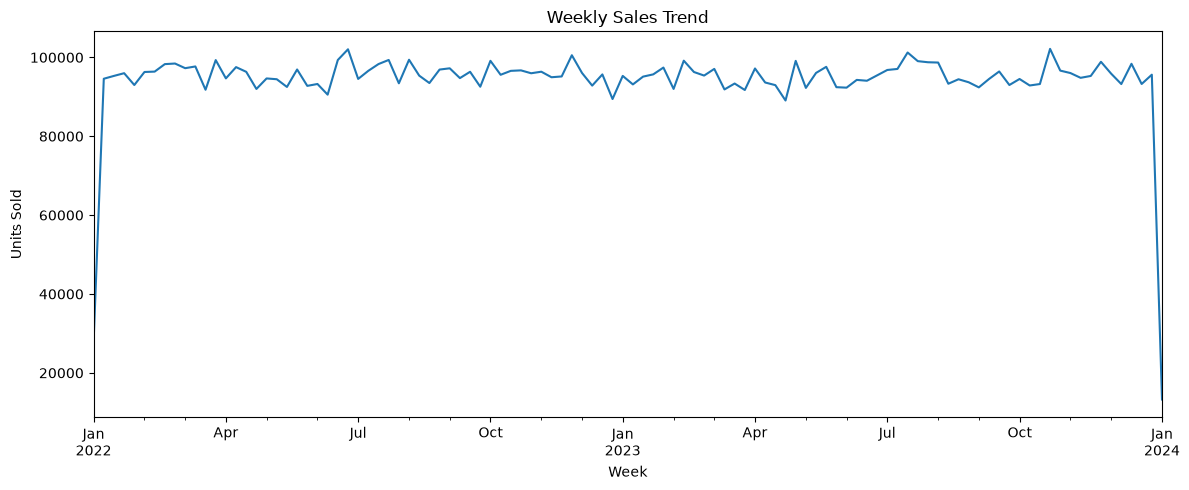

In [ ]:
weekly_sales = (
    df.groupby('YearWeek')['Units Sold']
      .sum()
)

plt.figure(figsize=(12, 5))

weekly_sales.plot()

plt.title('Weekly Sales Trend')
plt.xlabel('Week')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

# How do promotions impact demand?

In [ ]:
promo_sales = (
    df.groupby('Holiday/Promotion')['Units Sold']
      .mean()
)

promo_sales

Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64

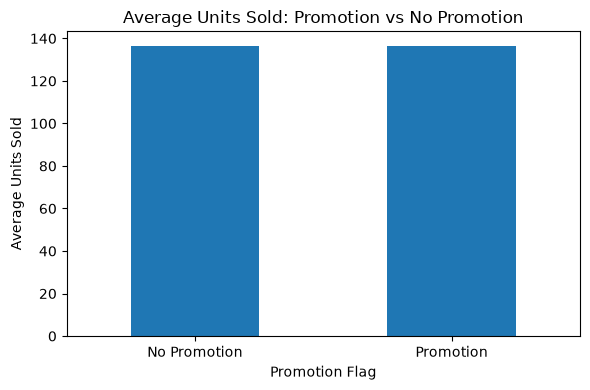

In [ ]:
plt.figure(figsize=(6, 4))

promo_sales.plot(kind='bar')

plt.title('Average Units Sold: Promotion vs No Promotion')
plt.xlabel('Promotion Flag')
plt.ylabel('Average Units Sold')

plt.xticks([0, 1], ['No Promotion', 'Promotion'], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
df['Holiday/Promotion'].value_counts()

Holiday/Promotion
0    36747
1    36353
Name: count, dtype: int64

# Which products are overstocked? (here 21 is considered as inventory_cover_days)

In [ ]:
inventory_cover = (
    df.groupby('Product ID')
      .agg({
          'Inventory Level': 'mean',
          'Units Sold': 'mean'
      })
)

inventory_cover['inventory_cover_days'] = (
    inventory_cover['Inventory Level'] /
    inventory_cover['Units Sold']
)

overstock = inventory_cover[
    inventory_cover['inventory_cover_days'] > 21
]

overstock.sort_values(
    by='inventory_cover_days',
    ascending=False
).head()

,Inventory Level,Units Sold,inventory_cover_days
Product ID,,,


No products have inventory_cover_days greater than 21

# Which products are frequently at stock-out risk?

In [ ]:
df['stockout_flag'] = np.where(
    df['Units Sold'] > df['Inventory Level'],
    1,
    0
)

stockout_products = (
    df.groupby('Product ID')['stockout_flag']
      .sum()
      .sort_values(ascending=False)
)

stockout_products.head(10)


Product ID
P0001    0
P0002    0
P0003    0
P0004    0
P0005    0
P0006    0
P0007    0
P0008    0
P0009    0
P0010    0
Name: stockout_flag, dtype: int64

No stock-out incidents detected

In [ ]:
# Method 3: Percentile method
# Values below 1st percentile or above 99th percentile are treated as extreme.

# Method 1: IQR method

q1 = df['Units Sold'].quantile(0.25)
q3 = df['Units Sold'].quantile(0.75)
iqr = q3 - q1

lower_limit_iqr = q1 - 1.5 * iqr
upper_limit_iqr = q3 + 1.5 * iqr

outliers_iqr = df[
    (df['Units Sold'] < lower_limit_iqr) |
    (df['Units Sold'] > upper_limit_iqr)
]

print("IQR lower limit:", round(lower_limit_iqr, 2))
print("IQR upper limit:", round(upper_limit_iqr, 2))
print("Number of outliers by IQR:", outliers_iqr.shape[0])

outliers_iqr.head()



IQR lower limit: -182.0
IQR upper limit: 434.0
Number of outliers by IQR: 715


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,YearMonth,YearWeek,stockout_flag
102,2022-01-02,S001,P0003,Clothing,South,488,464,163,463.12,70.99,10,Snowy,0,72.93,Summer,2022-01,2021-12-27/2022-01-02,0
138,2022-01-02,S002,P0019,Toys,East,492,479,132,469.74,79.11,0,Cloudy,0,80.06,Winter,2022-01,2021-12-27/2022-01-02,0
195,2022-01-02,S005,P0016,Groceries,East,487,437,106,432.86,43.64,15,Cloudy,1,39.13,Autumn,2022-01,2021-12-27/2022-01-02,0
322,2022-01-04,S002,P0003,Toys,North,493,448,113,459.44,41.55,15,Rainy,0,44.02,Winter,2022-01,2022-01-03/2022-01-09,0
554,2022-01-06,S003,P0015,Furniture,North,490,476,53,478.76,20.66,0,Rainy,1,16.87,Winter,2022-01,2022-01-03/2022-01-09,0


In [ ]:
# Option 1: Do nothing
# Use when outliers are genuine business events.

df_outlier_keep = df.copy()

# Option 2: Remove outliers using IQR
# Use only when outliers are confirmed as invalid or data errors.

df_outlier_removed = df[
    (df['Units Sold'] >= lower_limit_iqr) &
    (df['Units Sold'] <= upper_limit_iqr)
].copy()

# Option 3: Cap outliers using 1st and 99th percentile
# Use when extreme values are valid but should not dominate analysis/modeling.

df_outlier_capped = df.copy()
df_outlier_capped['Units Sold_capped'] = df_outlier_capped['Units Sold'].clip(lower=lower_p, upper=upper_p)

# Option 4: Create an outlier flag
# Use when outlier behavior is important and may carry signal.

df_outlier_flagged = df.copy()
df_outlier_flagged['is_Units Sold_outlier_iqr'] = (
    (df_outlier_flagged['Units Sold'] < lower_limit_iqr) |
    (df_outlier_flagged['Units Sold'] > upper_limit_iqr)
).astype(int)

print("Original rows:", df.shape[0])
print("Rows after removing IQR outliers:", df_outlier_removed.shape[0])
print("Outlier flag count:", df_outlier_flagged['is_UnitsSold_iqr'].sum())

NameError: name 'lower_p' is not defined

In [ ]:
# Method 3: Percentile method
# Values below 1st percentile or above 99th percentile are treated as extreme.

# Method 1: IQR method

q1 = df['Demand Forecast'].quantile(0.25)
q3 = df['Demand Forecast'].quantile(0.75)
iqr = q3 - q1

lower_limit_iqr = q1 - 1.5 * iqr
upper_limit_iqr = q3 + 1.5 * iqr

outliers_iqr = df[
    (df['Demand Forecast'] < lower_limit_iqr) |
    (df['Demand Forecast'] > upper_limit_iqr)
]

print("IQR lower limit:", round(lower_limit_iqr, 2))
print("IQR upper limit:", round(upper_limit_iqr, 2))
print("Number of outliers by IQR:", outliers_iqr.shape[0])

outliers_iqr.head()
